<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/My_Live_Handson/AI(Deep_Learning)/RNN_Handson_by_me.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 Problem Statement: IMDb Sentiment Classification using RNN

In the previous sessions, you explored neural networks and sequential deep learning concepts. Now it’s time to apply those concepts hands-on.

In this task, you will build a Recurrent Neural Network (RNN) model to classify IMDb movie reviews as positive or negative based on their text content.

🎭 About the Dataset

We will be using the IMDb Dataset (Internet Movie Reviews Dataset), available directly in TensorFlow/Keras.
It contains:

Component	Details
Total Reviews	50,000
Labels	Binary (0 = Negative, 1 = Positive)
Purpose	Sentiment classification
Split	25,000 training reviews + 25,000 test reviews

Every review is already converted into integer sequences, where each number represents a specific word from a vocabulary of the most frequent words.

🎯 Your Task

You must:

Load the IMDb dataset.

Preprocess the data (padding sequences).

Build an RNN-based model (You may use SimpleRNN)

Train the model.

Evaluate its performance using accuracy.

In [ ]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
num_words = 10000 #most frequent words in our data - ignoring all the rare words
(x_train,y_train),(x_test,y_test) = imdb.load_data(num_words=num_words )

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


num_words	 - integer or None. Words are ranked by how often they occur (in the training set) and only the num_words most frequent words are kept. Any less frequent word will appear as oov_char value in the sequence data. If None, all words are kept. Defaults to None.

In [ ]:
x_train.shape

(25000,)

In [ ]:
y_train.shape

(25000,)

In [ ]:
x_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [ ]:
x_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [ ]:
len(x_train[0])

218

In [ ]:
type(x_train)

numpy.ndarray

In [ ]:
type(x_train[0])

list

In [ ]:
y_train.shape

(25000,)

In [ ]:
lengths = np.array([len(x) for x in x_train])

In [ ]:
lengths

array([218, 189, 141, ..., 184, 150, 153])

In [ ]:
# varying lenghts, do padding

In [ ]:
lengths.max()

np.int64(2494)

In [ ]:
x_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [ ]:
len(x_train[0])

218

In [ ]:
x_train[0][:100]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16]

In [ ]:
MAX_LEN = 100

In [ ]:
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post') # by default both are pre
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding='post', truncating='post')

In [ ]:
len(x_train[0])

100

In [ ]:
x_train[0]

array([   1,   14,   22,   16,   43,  530,  973, 1622, 1385,   65,  458,
       4468,   66, 3941,    4,  173,   36,  256,    5,   25,  100,   43,
        838,  112,   50,  670,    2,    9,   35,  480,  284,    5,  150,
          4,  172,  112,  167,    2,  336,  385,   39,    4,  172, 4536,
       1111,   17,  546,   38,   13,  447,    4,  192,   50,   16,    6,
        147, 2025,   19,   14,   22,    4, 1920, 4613,  469,    4,   22,
         71,   87,   12,   16,   43,  530,   38,   76,   15,   13, 1247,
          4,   22,   17,  515,   17,   12,   16,  626,   18,    2,    5,
         62,  386,   12,    8,  316,    8,  106,    5,    4, 2223, 5244,
         16], dtype=int32)

In [ ]:
np.array([len(x) for x in x_train])

array([100, 100, 100, ..., 100, 100, 100])

In [ ]:
np.array([len(x) for x in x_train]).max()

np.int64(100)

In [ ]:
np.array([len(x) for x in x_train]).min()

np.int64(100)

In [ ]:
np.array([len(x) for x in x_test]).max()

np.int64(100)

In [ ]:
np.array([len(x) for x in x_test]).min()

np.int64(100)

In [ ]:
#random = 128, 64, 32, -> fine tune
def create_model():
  model = Sequential([
      Embedding(input_dim=num_words, output_dim=128, input_length=MAX_LEN),
      SimpleRNN(units=64, return_sequences=False),
      Dense(32, activation='relu'),
      Dense(1, activation='sigmoid')
  ])
  return model

In [ ]:
rnn_model = create_model()
rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import callbacks

In [ ]:
from tensorflow.keras.layers import Dropout

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
rnn_history = rnn_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
#    callbacks=[early_stopping]
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.9444 - loss: 0.1362 - val_accuracy: 0.7374 - val_loss: 0.9837
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.9850 - loss: 0.0423 - val_accuracy: 0.7130 - val_loss: 1.0794
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.9886 - loss: 0.0336 - val_accuracy: 0.6740 - val_loss: 1.4045
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.9964 - loss: 0.0128 - val_accuracy: 0.6416 - val_loss: 1.5648
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.9957 - loss: 0.0142 - val_accuracy: 0.5622 - val_loss: 2.0367
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9909 - loss: 0.0265 - val_accuracy: 0.6070 - val_loss: 1.9055
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.9976 - loss: 0.0085 - val_accuracy: 0.6656 - val_loss: 1.6752
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.9979 - loss: 0.0066 - 

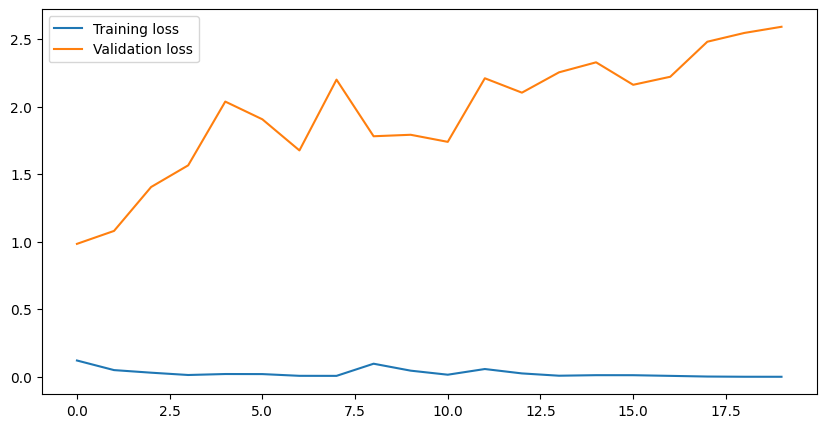

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history['loss'],label='Training loss')
plt.plot(rnn_history.history['val_loss'],label='Validation loss')
plt.legend()

In [ ]:
rnn_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

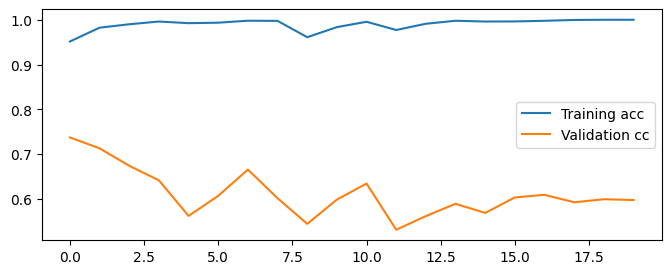

In [ ]:
plt.figure(figsize=(8,3))
plt.plot(rnn_history.history['accuracy'],label='Training acc')
plt.plot(rnn_history.history['val_accuracy'],label='Validation cc')
plt.legend()

In [ ]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,883,397 (14.81 MB)

 Trainable params: 1,294,465 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,588,932 (9.88 MB)

In [ ]:
model_loss, model_acc = rnn_model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6053 - loss: 2.5502


In [ ]:
model_loss

2.548663854598999

In [ ]:
model_acc

0.6018000245094299

In [ ]:
predictions = rnn_model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step


In [ ]:
predictions

array([[9.6720535e-01],
       [1.0000000e+00],
       [7.1527768e-04],
       ...,
       [2.6500374e-02],
       [9.6811050e-01],
       [9.9989432e-01]], dtype=float32)

In [ ]:
binary_predictions = (predictions >= 0.5).astype(int)

In [ ]:
binary_predictions

array([[1],
       [1],
       [0],
       ...,
       [0],
       [1],
       [1]])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy_score(y_test, binary_predictions)

0.6018

In [ ]:
classification_report(y_test, binary_predictions)

'              precision    recall  f1-score   support\n\n           0       0.60      0.60      0.60     12500\n           1       0.60      0.60      0.60     12500\n\n    accuracy                           0.60     25000\n   macro avg       0.60      0.60      0.60     25000\nweighted avg       0.60      0.60      0.60     25000\n'

In [ ]:
print(classification_report(y_test, binary_predictions))

              precision    recall  f1-score   support

           0       0.60      0.60      0.60     12500
           1       0.60      0.60      0.60     12500

    accuracy                           0.60     25000
   macro avg       0.60      0.60      0.60     25000
weighted avg       0.60      0.60      0.60     25000



In [ ]:
confusion_matrix(y_test, binary_predictions)

array([[7529, 4971],
       [4984, 7516]])